## Importing the libraries

In [2]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, confusion_matrix, f1_score, recall_score, RocCurveDisplay, ConfusionMatrixDisplay, PrecisionRecallDisplay, precision_recall_curve, auc, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [3]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

df = pd.read_csv("data/raw/synthetic_credit_risk.csv")

df.head()

Working directory: /Users/upanyachennoju/GitHub/credit-risk-system


,age,monthly_income,debt_ratio,credit_utilization,transaction_count_30d,avg_transaction_amount,employment_type,education_level,region,device_type,last_payment_delay_days,internal_score_v2,target
0,43.6,67139.59,0.341,0.508,44,56.04,contract,master,rural,desktop,0.30,546.3,0
1,42.3,69322.76,0.318,0.427,43,71.57,contract,master,urban,desktop,2.16,583.2,0
2,29.4,31240.70,0.380,0.519,43,88.01,full_time,high_school,suburban,tablet,1.14,544.0,0
3,52.5,23838.70,0.372,0.481,50,69.37,full_time,bachelor,urban,tablet,4.56,569.4,0
4,44.0,36584.21,0.129,0.213,44,93.56,contract,bachelor,urban,mobile,1.78,669.9,0


In [4]:
df.shape

(15000, 13)

## Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      15000 non-null  float64
 1   monthly_income           15000 non-null  float64
 2   debt_ratio               15000 non-null  float64
 3   credit_utilization       15000 non-null  float64
 4   transaction_count_30d    15000 non-null  int64  
 5   avg_transaction_amount   15000 non-null  float64
 6   employment_type          15000 non-null  str    
 7   education_level          15000 non-null  str    
 8   region                   15000 non-null  str    
 9   device_type              15000 non-null  str    
 10  last_payment_delay_days  15000 non-null  float64
 11  internal_score_v2        15000 non-null  float64
 12  target                   15000 non-null  int64  
dtypes: float64(7), int64(2), str(4)
memory usage: 1.9 MB


In [6]:
df.columns

Index(['age', 'monthly_income', 'debt_ratio', 'credit_utilization',
       'transaction_count_30d', 'avg_transaction_amount', 'employment_type',
       'education_level', 'region', 'device_type', 'last_payment_delay_days',
       'internal_score_v2', 'target'],
      dtype='str')

In [7]:
df.describe()

,age,monthly_income,debt_ratio,credit_utilization,transaction_count_30d,avg_transaction_amount,last_payment_delay_days,internal_score_v2,target
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,45.557853,43234.147455,0.334668,0.400615,43.333800,92.102736,2.586447,587.514093,0.077200
std,11.014118,21169.380032,0.154811,0.196154,8.584231,35.616869,3.416169,57.425613,0.266917
min,18.000000,4024.160000,0.000000,0.000000,18.000000,10.000000,0.000000,276.500000,0.000000
25%,38.200000,28488.085000,0.229000,0.265000,38.000000,67.320000,0.650000,557.700000,0.000000
50%,45.600000,39141.395000,0.328000,0.392000,42.000000,91.655000,1.620000,592.600000,0.000000
75%,52.900000,53188.735000,0.431000,0.521000,47.000000,115.682500,3.260000,624.825000,0.000000
max,75.000000,205203.980000,1.000000,1.000000,95.000000,239.500000,50.430000,750.200000,1.000000


### Check for Missing Values

In [8]:
missing_values = df.isnull().sum()
missing_values_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_values_percent
})

missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing Percentage


It appears there are no missing values in the dataset. Next, let's explore the unique values and distributions of the categorical features.

In [9]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nUnique values for '{col}':")
    print(df[col].value_counts())
    print(f"Number of unique values: {df[col].nunique()}")


Unique values for 'employment_type':
employment_type
full_time        8783
self_employed    2755
contract         2158
unemployed       1304
Name: count, dtype: int64
Number of unique values: 4

Unique values for 'education_level':
education_level
bachelor       6011
high_school    5415
master         2846
phd             728
Name: count, dtype: int64
Number of unique values: 4

Unique values for 'region':
region
urban       7765
suburban    4529
rural       2706
Name: count, dtype: int64
Number of unique values: 3

Unique values for 'device_type':
device_type
mobile     9433
desktop    4218
tablet     1349
Name: count, dtype: int64
Number of unique values: 3


/var/folders/df/6ml_7hkj4zl3cjxy_v07ggyh0000gn/T/ipykernel_27760/1641531108.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


### Visualizing Distributions of Categorical Features

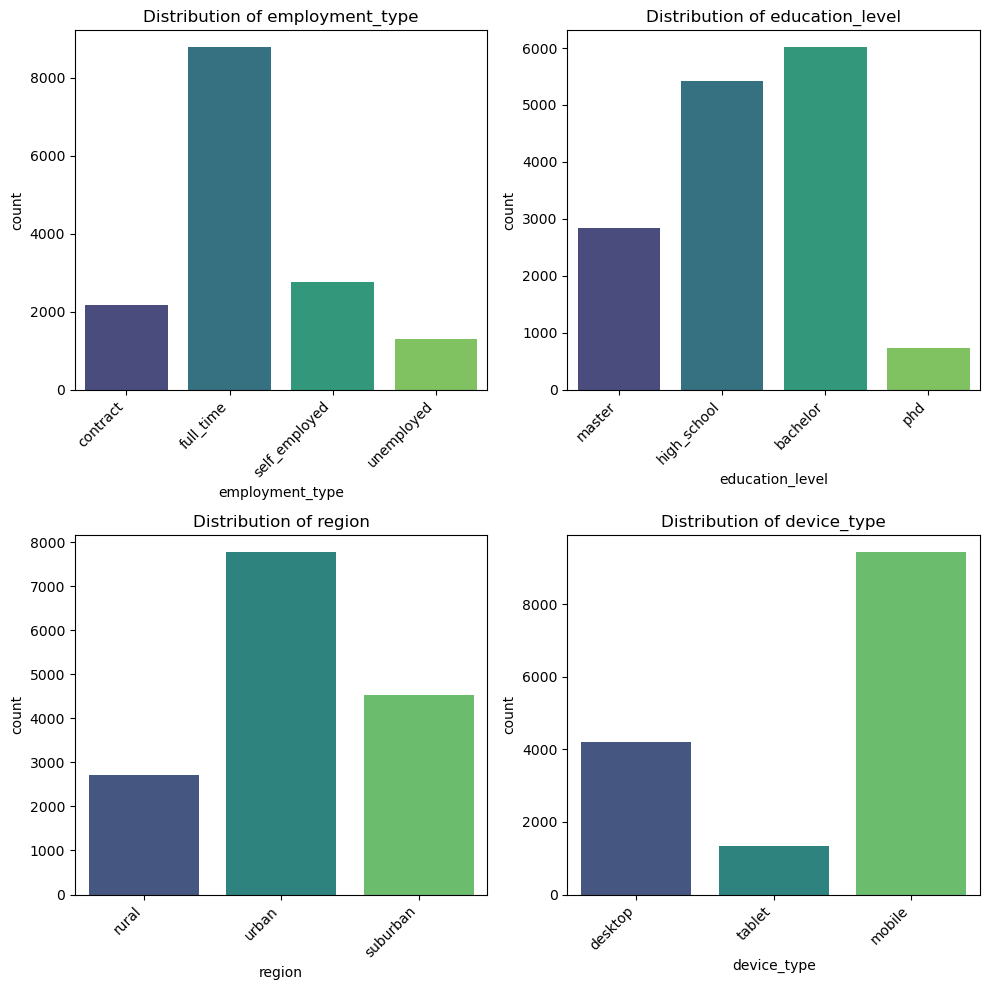

In [10]:
plt.figure(figsize=(10, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid based on number of categorical columns
    sns.countplot(data=df, x=col, palette='viridis', hue=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualizing Distributions of Numerical Features

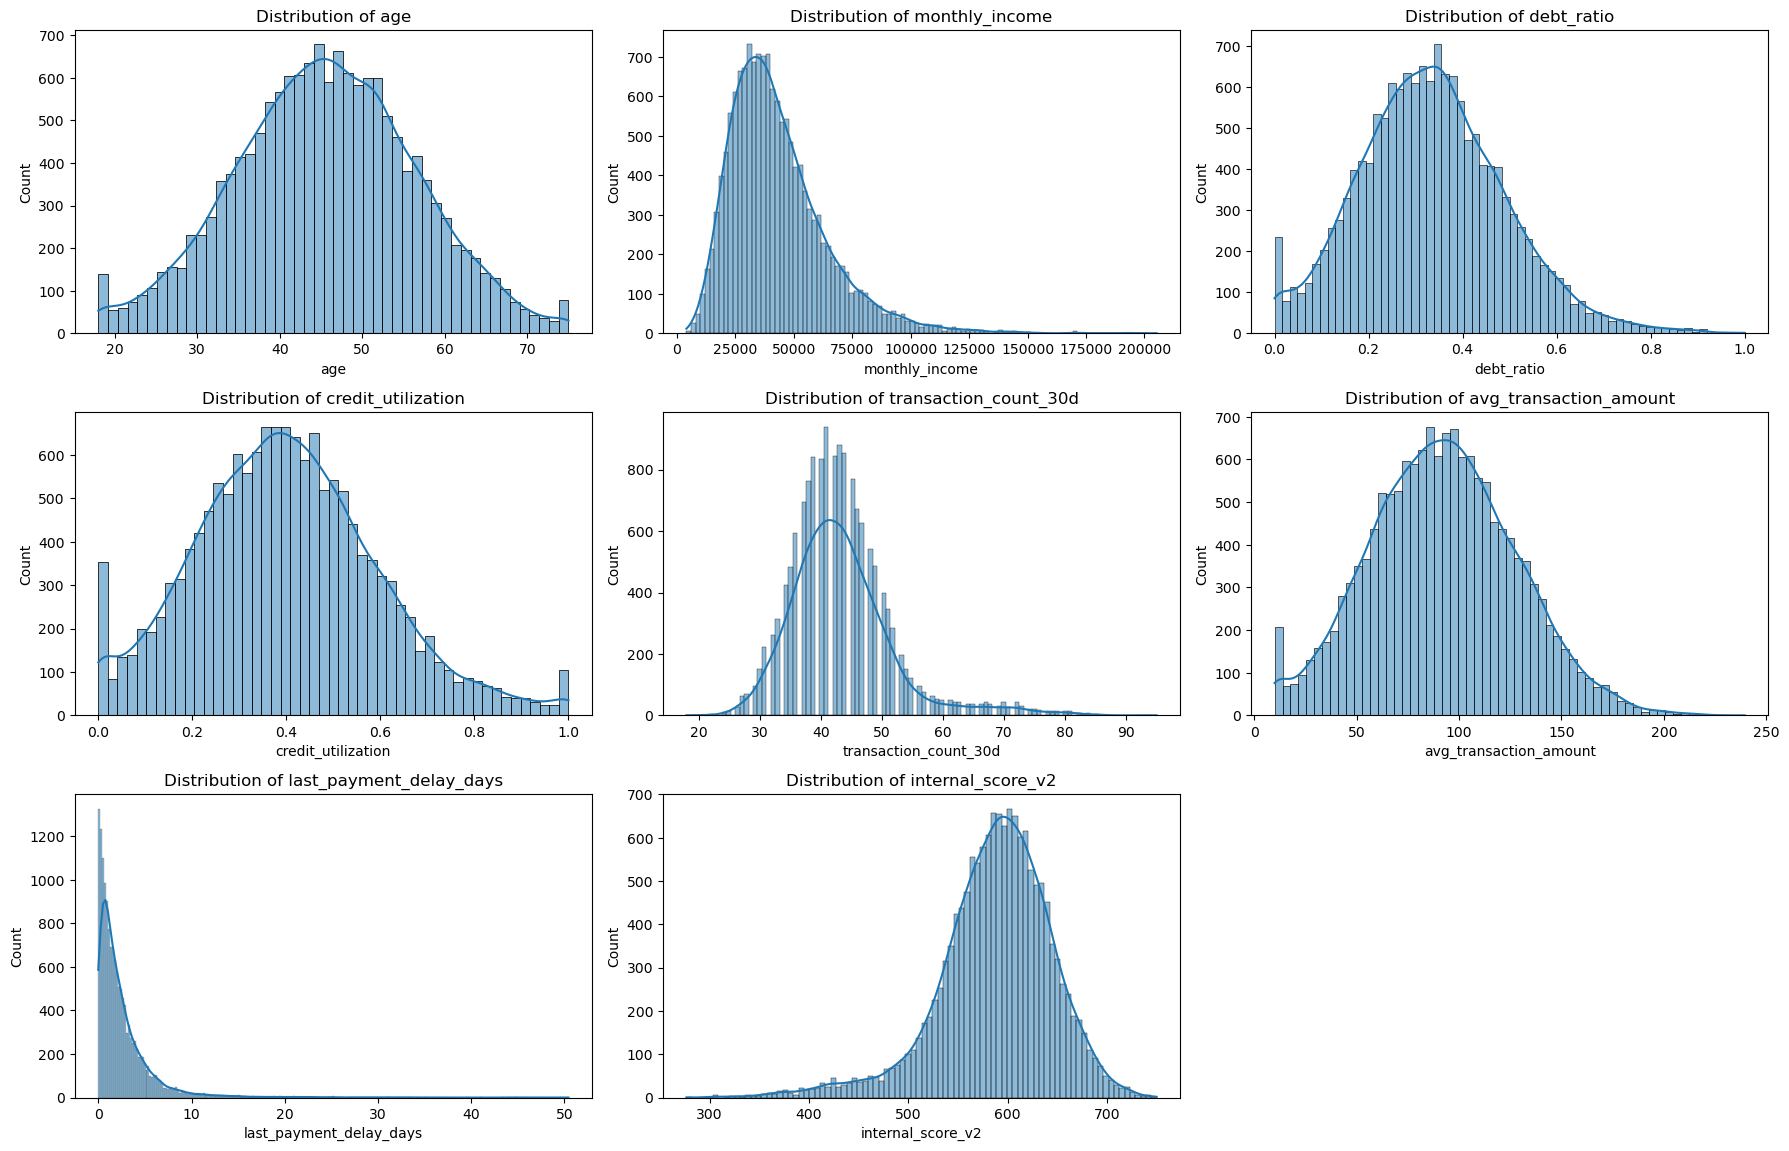

In [11]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('target')

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Target Variable Distribution

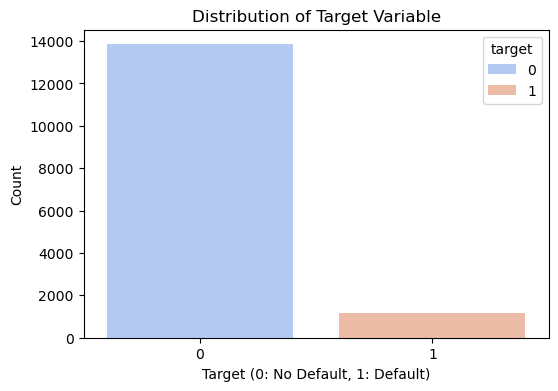

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='coolwarm', hue='target')
plt.title('Distribution of Target Variable')
plt.xlabel('Target (0: No Default, 1: Default)')
plt.ylabel('Count')
plt.show()

In [13]:
target_distribution = df['target'].value_counts(normalize=True) * 100
target_distribution.to_frame(name='Percentage')

,Percentage
target,
0,92.28
1,7.72


### correlation matrix

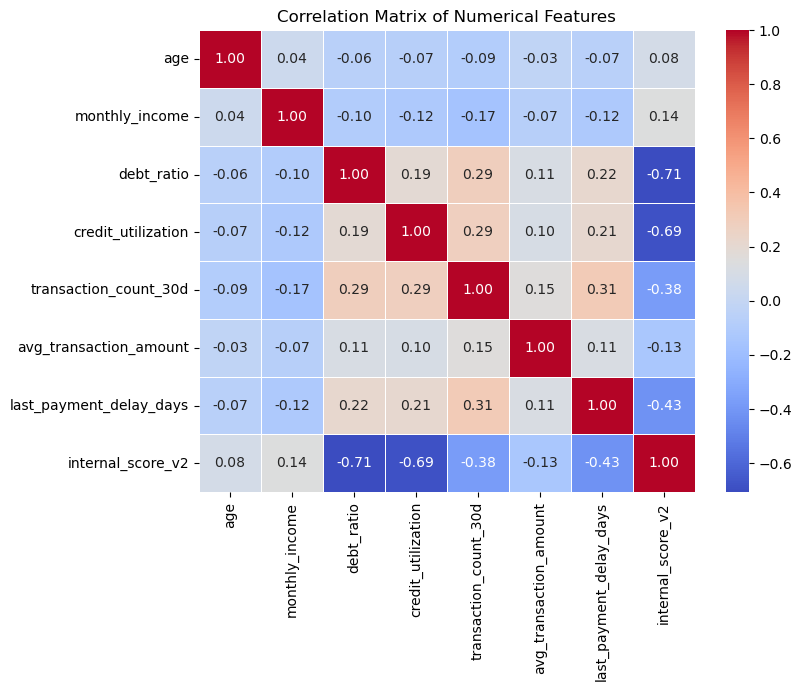

In [14]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Train-Test-Split

In [15]:
X = df.drop('target', axis=1)
y = df['target']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (12000, 12)
y_train shape: (12000,)
X_test shape: (3000, 12)
y_test shape: (3000,)


### Encoding

In [17]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('target')

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

/var/folders/df/6ml_7hkj4zl3cjxy_v07ggyh0000gn/T/ipykernel_27760/1389576452.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


## Logistic Regression

In [39]:
lr_model_no_smote = LogisticRegression(class_weight='balanced', random_state=42)
lr_model_no_smote.fit(X_train_encoded, y_train)

# Predict probabilities
y_prob = lr_model_no_smote.predict_proba(X_test_encoded)[:, 1]
'''
# Apply threshold
for threshold in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
  lr_no_smote_preds = (y_prob >= threshold).astype(int)

  # Metrics
  print(f"\nThreshold: {threshold}")
  print(f"Precision: {precision_score(y_test, lr_no_smote_preds):.4f}")
  print(f"Recall: {recall_score(y_test, lr_no_smote_preds):.4f}")
  print(f"f1 score: {f1_score(y_test, lr_no_smote_preds):.4f}")
  print(f"Confusion matrix:\n{confusion_matrix(y_test, lr_no_smote_preds)}")
'''
threshold = 0.80
lr_no_smote_preds = (y_prob >= threshold).astype(int)

print(f"\nThreshold: {threshold}")
print(f"Precision: {precision_score(y_test, lr_no_smote_preds):.4f}")
print(f"Recall: {recall_score(y_test, lr_no_smote_preds):.4f}")
print(f"f1 score: {f1_score(y_test, lr_no_smote_preds):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, lr_no_smote_preds)}")

# Probability distribution
print(y_prob.min())
print(y_prob.max())
print(y_prob.mean())


Threshold: 0.8
Precision: 0.9551
Recall: 0.6422
f1 score: 0.7680
Confusion matrix:
[[2761    7]
 [  83  149]]
0.040445018890140086
0.9992346302885631
0.3297051873239769


0.8


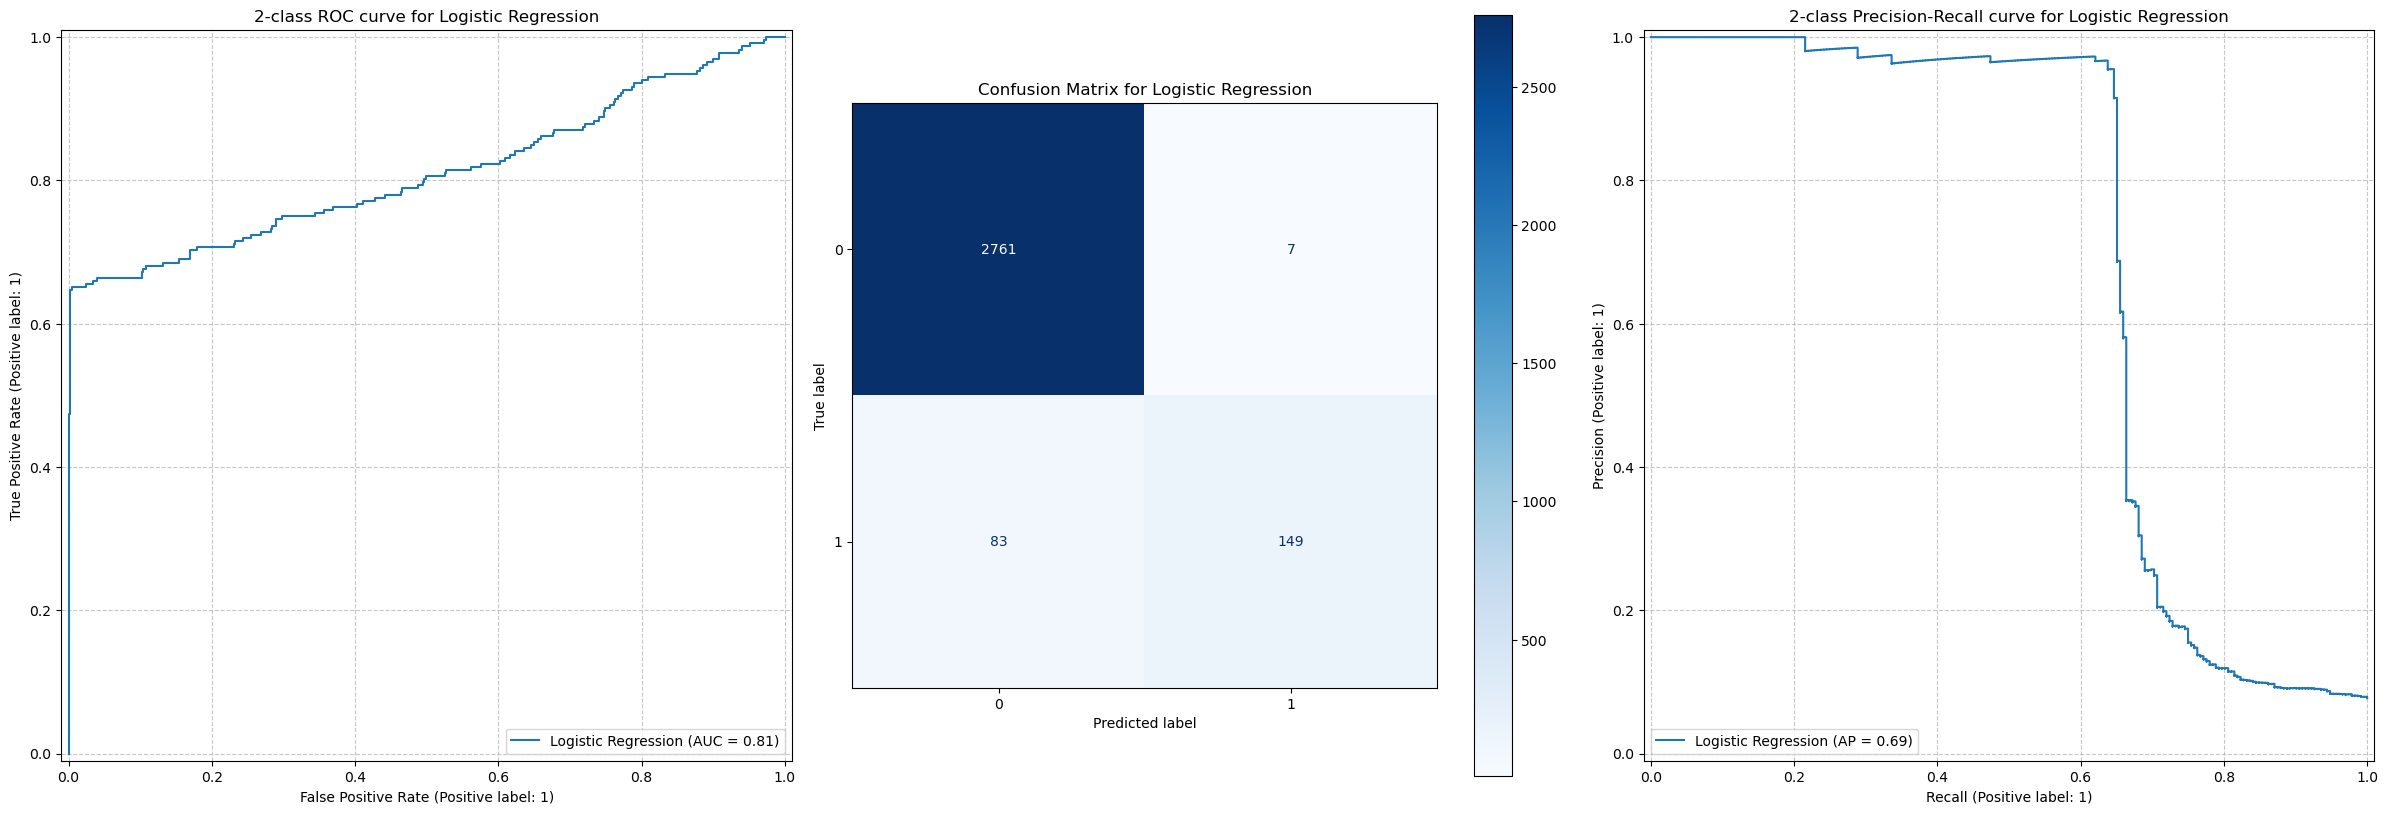

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
print(threshold)
RocCurveDisplay.from_estimator(
    lr_model_no_smote, X_test_encoded, y_test, name="Logistic Regression", ax=axes[0]
)
axes[0].set_title("2-class ROC curve for Logistic Regression")
axes[0].grid(True, linestyle='--', alpha=0.7)

ConfusionMatrixDisplay.from_predictions(y_test, lr_no_smote_preds, cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix for Logistic Regression')

PrecisionRecallDisplay.from_estimator(
    lr_model_no_smote, X_test_encoded, y_test, name="Logistic Regression", ax=axes[2]
)
axes[2].set_title('2-class Precision-Recall curve for Logistic Regression')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Random Forest Classifier

In [48]:
rf_model_no_smote = RandomForestClassifier(class_weight='balanced', random_state=42,
                                        n_estimators=172, max_depth=5, max_features=None,
                                        min_samples_leaf=3, min_samples_split=2)
rf_model_no_smote.fit(X_train_encoded, y_train)

rf_no_smote_preds = rf_model_no_smote.predict(X_test_encoded)

print(f"Precision for RF: {precision_score(y_test, rf_no_smote_preds, zero_division=0):.4f}")
print(f"Recall for RF: {recall_score(y_test, rf_no_smote_preds, zero_division=0):.4f}")

Precision for RF: 0.8855
Recall for RF: 0.6336


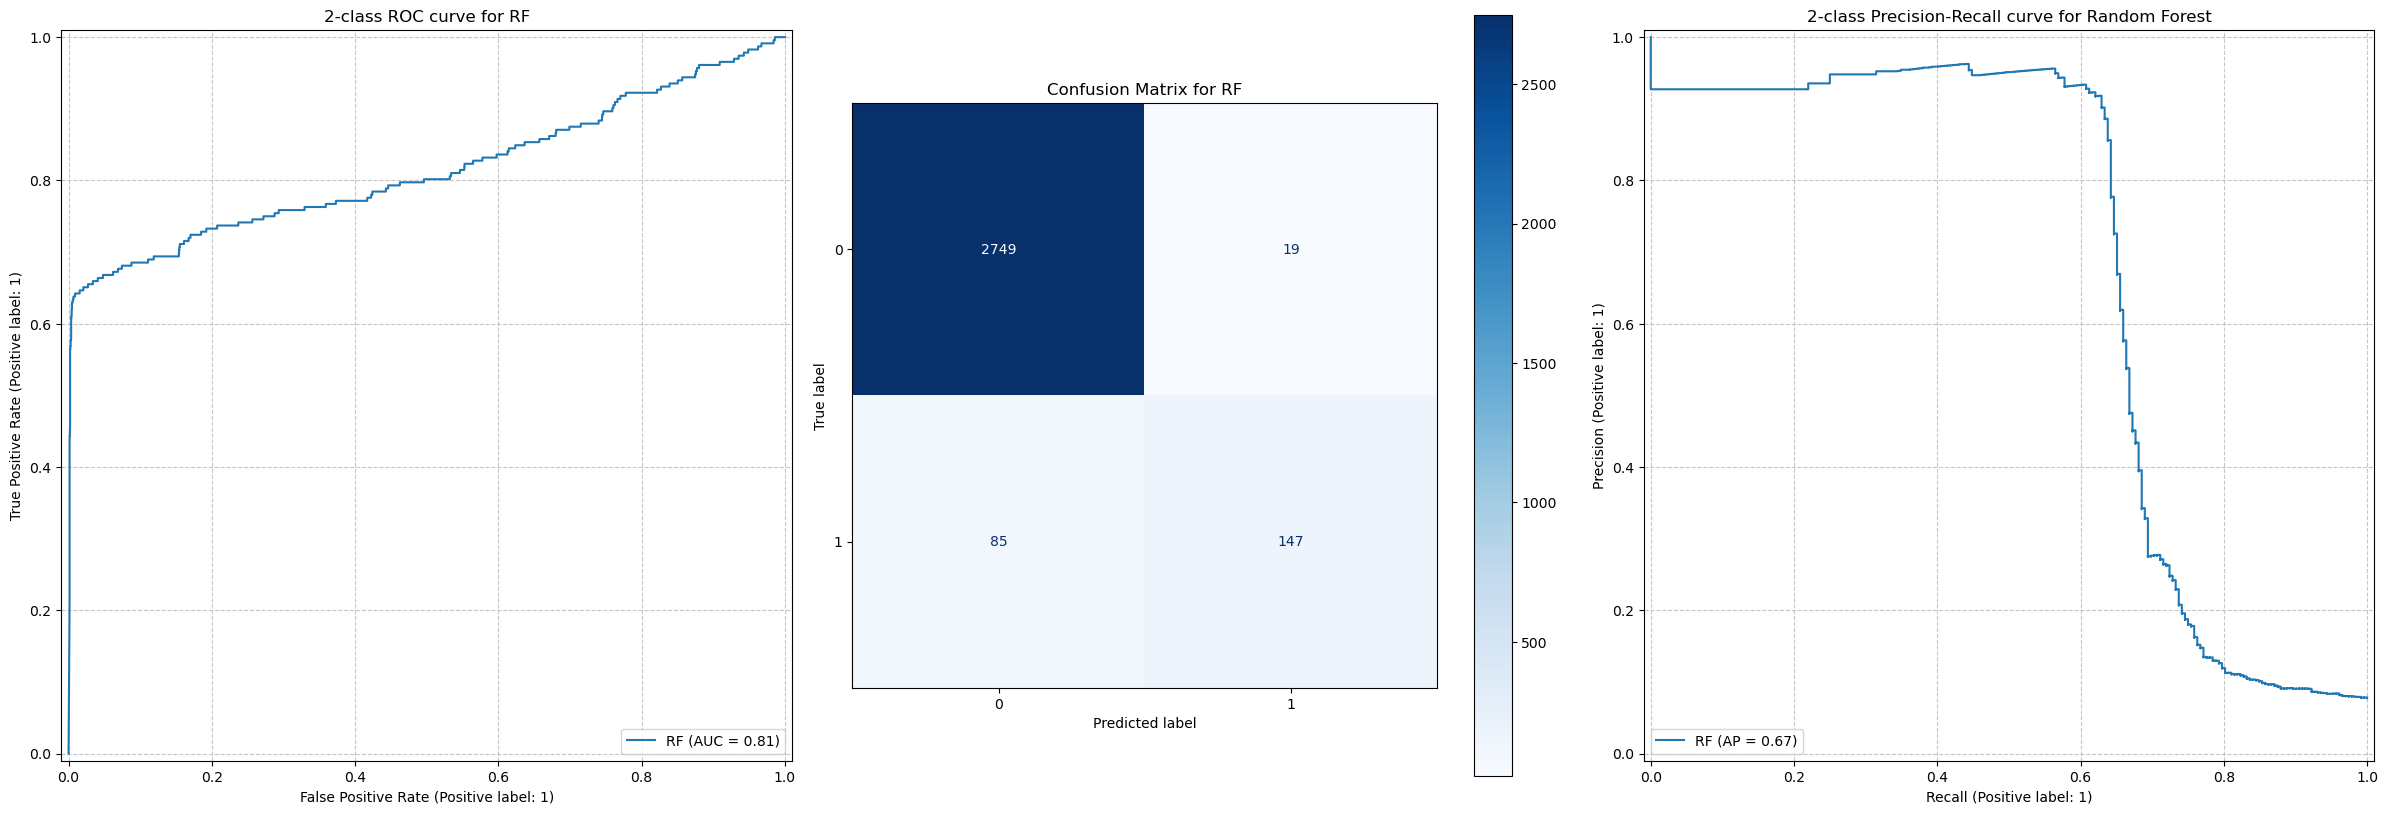

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

RocCurveDisplay.from_estimator(
    rf_model_no_smote, X_test_encoded, y_test, name="RF", ax=axes[0]
)
axes[0].set_title("2-class ROC curve for RF")
axes[0].grid(True, linestyle='--', alpha=0.7)

ConfusionMatrixDisplay.from_predictions(y_test, rf_no_smote_preds, cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix for RF')

PrecisionRecallDisplay.from_estimator(
    rf_model_no_smote, X_test_encoded, y_test, name="RF", ax=axes[2]
)
axes[2].set_title('2-class Precision-Recall curve for Random Forest')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## XGBoost Classifier

In [44]:
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
#scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model_no_smote = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    #scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model_no_smote.fit(X_train_encoded, y_train)
xgb_y_prob = xgb_model_no_smote.predict_proba(X_test_encoded)[:, 1]

threshold=0.3
xgb_no_smote_preds = (xgb_y_prob >= threshold).astype(int)

"""
for threshold in [0.02, 0.03, 0.05, 0.1, 0.2, 0.3]:
  xgb_no_smote_preds = (xgb_y_prob >= threshold).astype(int)

  # Metrics
  print(f"\nThreshold: {threshold}")
  print(f"Precision: {precision_score(y_test, xgb_no_smote_preds, zero_division=0):.4f}")
  print(f"Recall: {recall_score(y_test, xgb_no_smote_preds, zero_division=0):.4f}")
  print(f"f1 score: {f1_score(y_test, xgb_no_smote_preds):.4f}")
  print(f"Confusion matrix:\n{confusion_matrix(y_test, xgb_no_smote_preds)}")

print(xgb_y_prob.min())
print(xgb_y_prob.max())
print(xgb_y_prob.mean())
"""
print(f"Precision for XGBoost: {precision_score(y_test, xgb_no_smote_preds, zero_division=0):.4f}")
print(f"Recall for XGBoost: {recall_score(y_test, xgb_no_smote_preds, zero_division=0):.4f}")


Precision for XGBoost: 0.9036
Recall for XGBoost: 0.6466


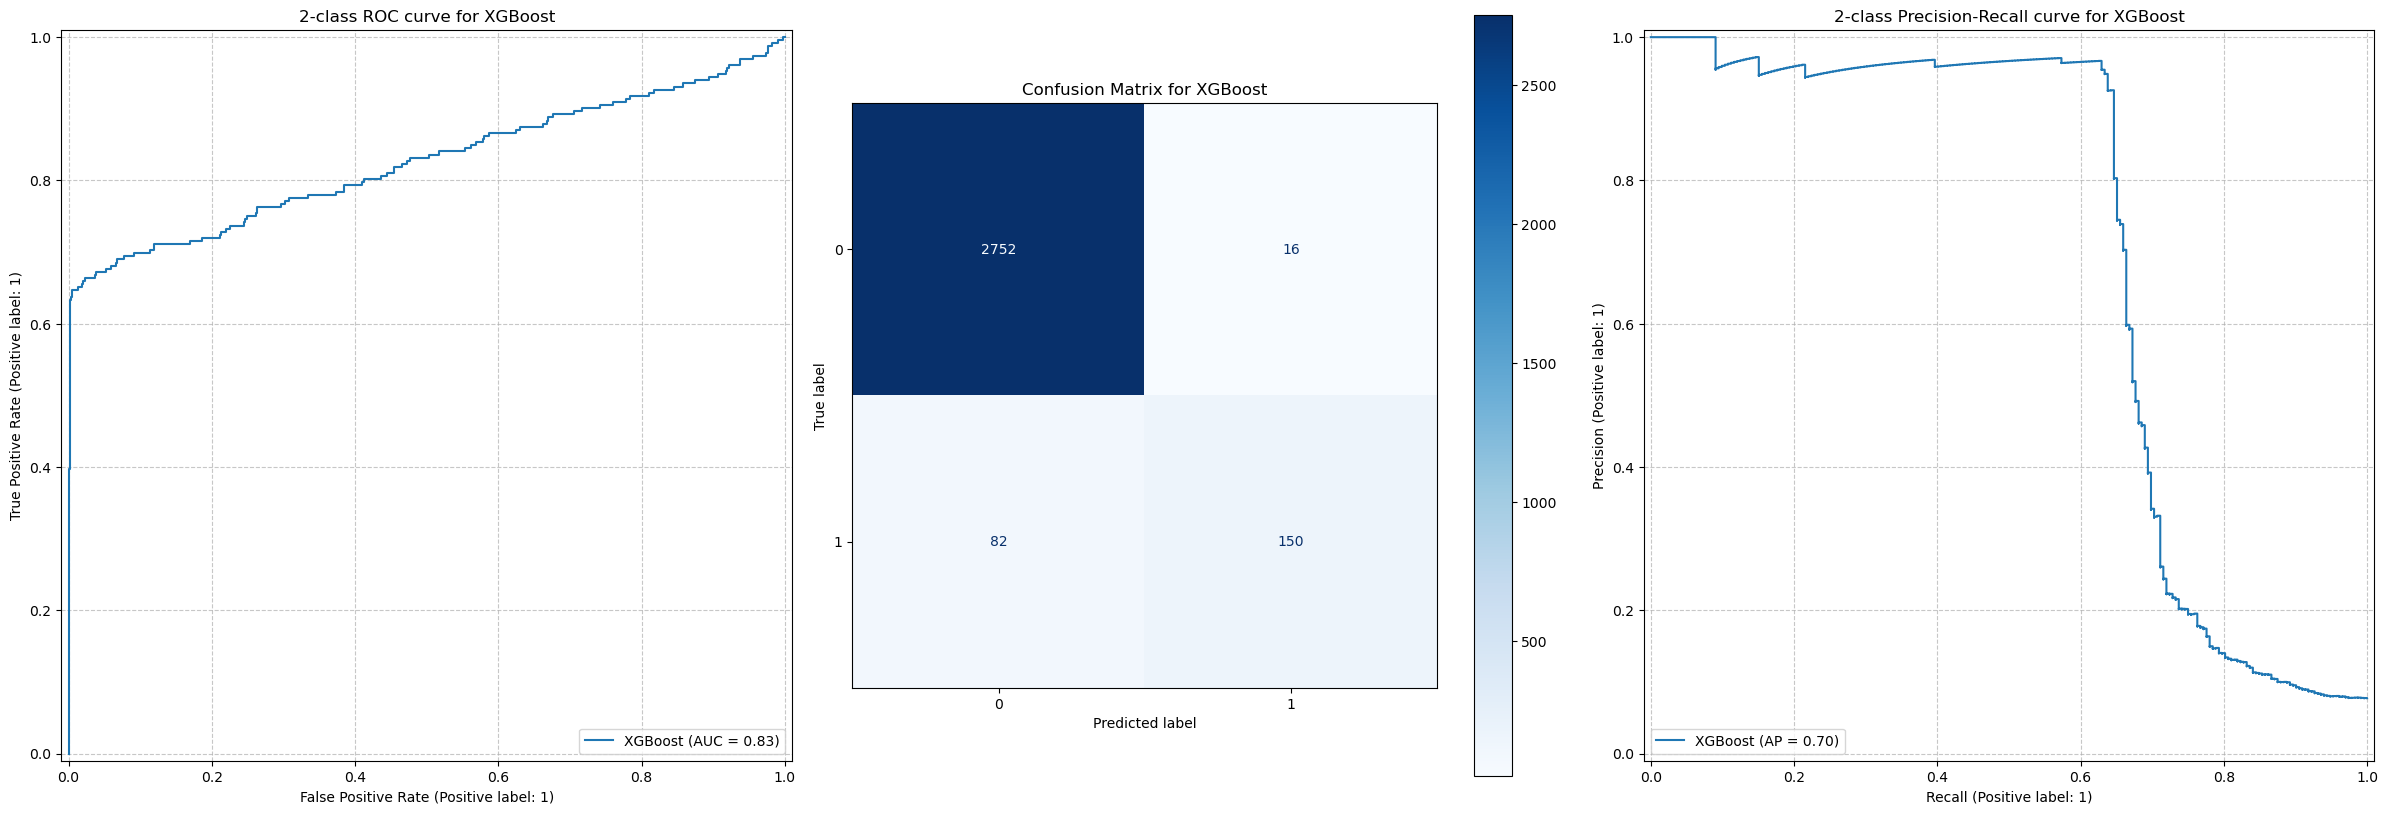

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

RocCurveDisplay.from_estimator(
    xgb_model_no_smote, X_test_encoded, y_test, name="XGBoost", ax=axes[0]
)
axes[0].set_title("2-class ROC curve for XGBoost")
axes[0].grid(True, linestyle='--', alpha=0.7)

ConfusionMatrixDisplay.from_predictions(y_test, xgb_no_smote_preds, cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix for XGBoost')

PrecisionRecallDisplay.from_estimator(
    xgb_model_no_smote, X_test_encoded, y_test, name="XGBoost", ax=axes[2]
)
axes[2].set_title('2-class Precision-Recall curve for XGBoost')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Summary of metrics without SMOTE

In [50]:
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [
        precision_score(y_test, lr_no_smote_preds, zero_division=0),
        precision_score(y_test, rf_no_smote_preds, zero_division=0),
        precision_score(y_test, xgb_no_smote_preds, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, lr_no_smote_preds, zero_division=0),
        recall_score(y_test, rf_no_smote_preds, zero_division=0),
        recall_score(y_test, xgb_no_smote_preds, zero_division=0)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.round(4))


,Model,Precision,Recall
0,Logistic Regression,0.9551,0.6422
1,Random Forest,0.8855,0.6336
2,XGBoost,0.9036,0.6466


## SMOTE

In [51]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)

print(f"Shape of X_train_resampled: {X_train_resampled.shape}")
print(f"Shape of y_train_resampled: {y_train_resampled.shape}")
print(f"Distribution of y_train_resampled:\n{y_train_resampled.value_counts()}")

Shape of X_train_resampled: (22148, 22)
Shape of y_train_resampled: (22148,)
Distribution of y_train_resampled:
target
0    11074
1    11074
Name: count, dtype: int64


In [52]:
lr_model_smote = LogisticRegression(max_iter=300, solver='saga', class_weight='balanced', random_state=42)
lr_model_smote.fit(X_train_resampled, y_train_resampled)
lr_smote_preds = lr_model_smote.predict(X_test_encoded)

print(f"Precision for LR: {precision_score(y_test, lr_smote_preds)}")
print(f"Recall for LR: {recall_score(y_test, lr_smote_preds)}")

lr_smote_probs = lr_model_smote.predict_proba(X_test_encoded)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, lr_smote_probs)

pr_auc = auc(recall, precision)
print(f"Area under Precision Recall curve: {pr_auc:.4f}")

Precision for LR: 0.3870967741935484
Recall for LR: 0.6724137931034483
Area under Precision Recall curve: 0.6940


/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


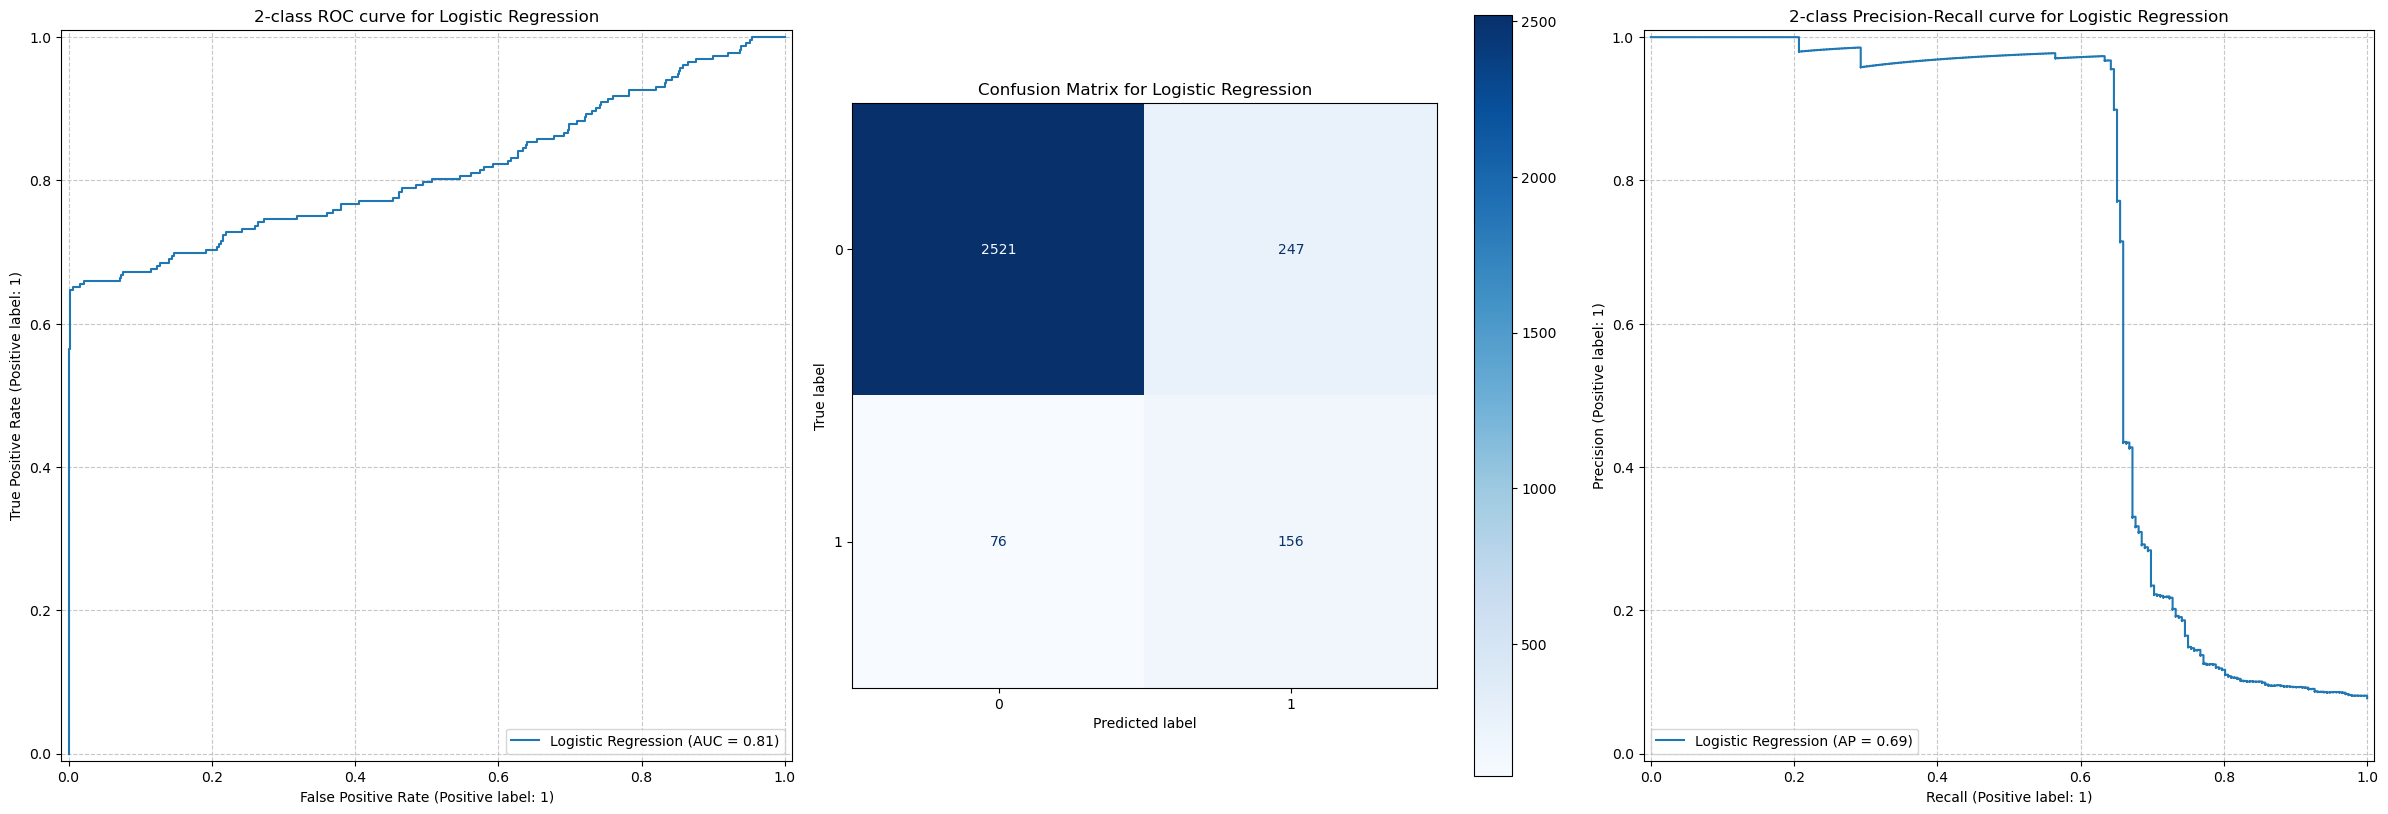

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

RocCurveDisplay.from_estimator(
    lr_model_smote, X_test_encoded, y_test, name="Logistic Regression", ax=axes[0]
)
axes[0].set_title("2-class ROC curve for Logistic Regression")
axes[0].grid(True, linestyle='--', alpha=0.7)

ConfusionMatrixDisplay.from_predictions(y_test, lr_smote_preds, cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix for Logistic Regression')

PrecisionRecallDisplay.from_estimator(
    lr_model_smote, X_test_encoded, y_test, name="Logistic Regression", ax=axes[2]
)
axes[2].set_title('2-class Precision-Recall curve for Logistic Regression')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning

### Tuning for XGBoost

In [28]:
param_dist_xgb = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.2),
    'use_label_encoder': [False],
    'eval_metric': ['logloss']
}

neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

xgb_base = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)

random_search_xgb = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_xgb.fit(X_train_encoded, y_train)

print("Best parameters for XGBoost:", random_search_xgb.best_params_)
print("Best recall score on validation set:", random_search_xgb.best_score_)

best_xgb = random_search_xgb.best_estimator_
best_xgb_preds = best_xgb.predict(X_test_encoded)

print(f"\nPrecision for Tuned XGBoost: {precision_score(y_test, best_xgb_preds):.4f}")
print(f"Recall for Tuned XGBoost: {recall_score(y_test, best_xgb_preds):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:10:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:10:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:10:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:10:19] WARNING: /Users/runner/work/xgbo

Best parameters for XGBoost: {'colsample_bytree': np.float64(0.8989280440549523), 'eval_metric': 'logloss', 'gamma': np.float64(0.10793842647781596), 'learning_rate': np.float64(0.18602534969915446), 'max_depth': 3, 'n_estimators': 173, 'subsample': np.float64(0.7103996728090174), 'use_label_encoder': False}
Best recall score on validation set: 0.6414530659691949

Precision for Tuned XGBoost: 0.6375
Recall for Tuned XGBoost: 0.6595


###Tuning for Logistic Regression

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced']
}

grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=200),
    param_grid_lr,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_encoded, y_train)

print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best recall score on validation set:", grid_search_lr.best_score_)

best_lr = grid_search_lr.best_estimator_
best_lr_preds = best_lr.predict(X_test_encoded)

print(f"\nPrecision for Tuned LR: {precision_score(y_test, best_lr_preds):.4f}")
print(f"Recall for Tuned LR: {recall_score(y_test, best_lr_preds):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters for Logistic Regression: {'C': 0.001, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best recall score on validation set: 0.6684394071490847

Precision for Tuned LR: 0.3515
Recall for Tuned LR: 0.6681


/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/upanyachennoju/miniconda3/envs/mlops/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Tuning for Random Forest

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'n_estimators': randint(50, 300),
    'max_features': ['sqrt', 'log2', None],
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'class_weight': ['balanced']
}

rf_base = RandomForestClassifier(random_state=42)

random_search_rf = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_rf.fit(X_train_encoded, y_train)

print("Best parameters for Random Forest:", random_search_rf.best_params_)
print("Best recall score on validation set:", random_search_rf.best_score_)

best_rf = random_search_rf.best_estimator_
best_rf_preds = best_rf.predict(X_test_encoded)

print(f"\nPrecision for Tuned Random Forest: {precision_score(y_test, best_rf_preds, zero_division=0):.4f}")
print(f"Recall for Tuned Random Forest: {recall_score(y_test, best_rf_preds, zero_division=0):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters for Random Forest: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 9, 'min_samples_split': 14, 'n_estimators': 282}
Best recall score on validation set: 0.6241732054635281

Precision for Tuned Random Forest: 0.8389
Recall for Tuned Random Forest: 0.6509


experiment_notes:
  - No missing values in dataset
  - Class imbalance present (handled via class_weight + threshold tuning)
  - SMOTE removed: threshold tuning is more effective
  - All models benefit from class_weight='balanced'
  - XGBoost and RF outperform LR with proper hyperparameter tuning
  - Threshold tuning is critical - default 0.5 may not be optimal
  - Current strategy: Optimize thresholds per model for precision-recall tradeoff
  - Recommendation: Use threshold tuning for class imbalance (simpler + more effective)